In [1]:
import xarray as xr

alexandria_waves = xr.open_dataset("inputs/waves/ERA5_bulk_waves.nc")
alexandria_waves

<xarray.Dataset> Size: 150MB
Dimensions:     (valid_time: 750960, latitude: 4, longitude: 4)
Coordinates:
  * latitude    (latitude) float64 32B 32.0 31.5 31.0 30.5
  * longitude   (longitude) float64 32B 29.0 29.5 30.0 30.5
    meanSea     float64 8B ...
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-08-31T23:...
Data variables:
    swh         (valid_time, latitude, longitude) float32 48MB ...
    pp1d        (valid_time, latitude, longitude) float32 48MB ...
    mwd         (valid_time, latitude, longitude) float32 48MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-05-05T16:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

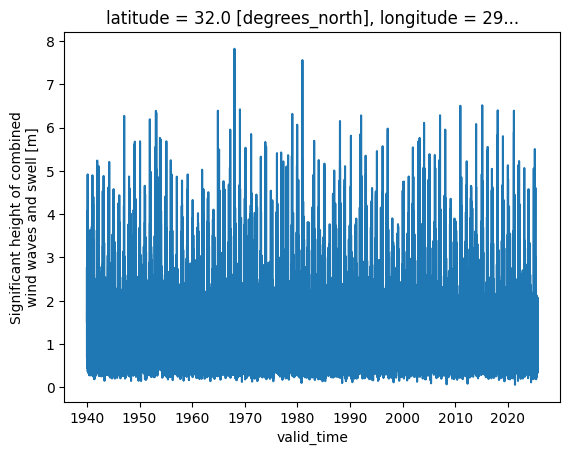

In [2]:
alexandria_waves.isel(latitude=0, longitude=0).swh.plot()

In [3]:
import pandas as pd

# Globe_RivDIS.dat Monthly average discharge in cubic meters/sec 262791 records
river_discharge = pd.read_csv("inputs/river_discharge/RIVDIS.DAT", sep="|")
# Globe_RivDIS.stn  1020
stations_info = pd.read_csv("inputs/river_discharge/STATION.DAT", sep="|")

In [4]:
stations_info.where(stations_info.RIVER == "Nile").dropna()

,POINTID,STATION,RIVER,LAT,LON,MAPCODE,ELEV,COUNTRY,CONT,OCEAN,BASIN,BASN_STN,AREA,NXT_PNT,RELIABLE,REASON
42,76.0,Dongola,Nile,19.18,30.48,F3,212,Sudan,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1487,1.0,
739,1159.0,El Ekhsase,Nile,29.71,31.26,F2,20,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,,1.0,
740,1160.0,Assiut,Nile,27.18,31.10,F2,51,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1159,1.0,
741,1162.0,Nag Hammadi,Nile,26.21,32.00,F2,69,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1160,1.0,
742,1166.0,Esna,Nile,25.43,32.55,F2,80,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1162,1.0,
743,1167.0,Gaafra,Nile,24.31,32.90,F2,85,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1166,1.0,
956,1487.0,Aswan Dam,Nile,23.96,32.90,,,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1167,1.0,


In [5]:
river_discharge_station = river_discharge.where(
    river_discharge.POINTID == 1167
).dropna()
river_discharge_station.DISCHRG = river_discharge_station.DISCHRG.astype(float)
river_discharge_station.set_index(
    pd.to_datetime(
        [
            f"{int(year)}-{int(month)}"
            for year, month in zip(
                river_discharge_station.YEAR, river_discharge_station.MONTH
            )
        ],
        yearfirst=True,
    ),
    inplace=True,
)
river_discharge_station

,POINTID,YEAR,MONTH,DISCHRG
1973-01-01,1167.0,1973.0,1.0,1336.0
1973-02-01,1167.0,1973.0,2.0,1450.0
1973-03-01,1167.0,1973.0,3.0,1609.0
1973-04-01,1167.0,1973.0,4.0,1523.0
1973-05-01,1167.0,1973.0,5.0,1922.0
...,...,...,...,...
1984-08-01,1167.0,1984.0,8.0,2350.0
1984-09-01,1167.0,1984.0,9.0,1840.0
1984-10-01,1167.0,1984.0,10.0,1725.0
1984-11-01,1167.0,1984.0,11.0,1493.0


<Axes: >

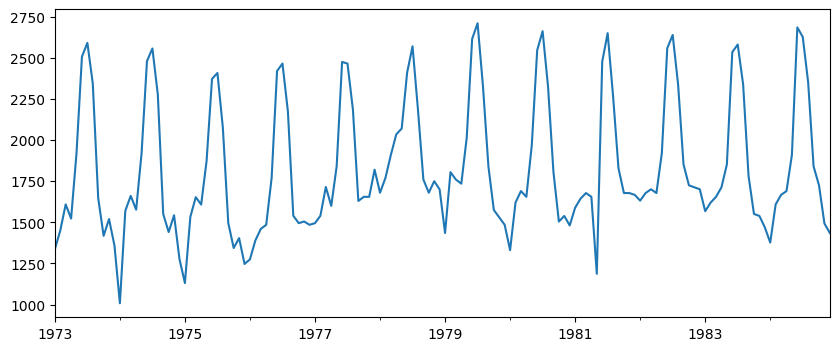

In [6]:
river_discharge_station.DISCHRG.plot(figsize=(10, 4))

In [7]:
gesla_info = pd.read_csv("inputs/sea_level/GESLA4_ALL.csv")
gesla_info[gesla_info.COUNTRY == "EGY"]

,FILE NAME,SITE NAME,SITE CODE,COUNTRY,CONTRIBUTOR (ABBREVIATED),CONTRIBUTOR (FULL),CONTRIBUTOR WEBSITE,CONTRIBUTOR CONTACT,ORGINATOR,ORIGINATOR WEBSITE,...,START DATE/TIME,END DATE/TIME,NUMBER OF YEARS,TIME ZONE HOURS,DATUM INFORMATION,INSTRUMENT,PRECISION,NULL VALUE,GAUGE TYPE,OVERALL RECORD QUALITY
516,alexandria-807a-egy-uhslc_rq,Alexandria,807A,EGY,UHSLC_RQ,University of Hawaii Sea Level Center,https://uhslc.soest.hawaii.edu,philiprt@hawaii.edu,National Oceanography Centre (NOC) United Ki...,Unspecified,...,2009/11/06 15:00:00,2016/01/17 14:00:00,8,0,Unspecified,Unspecified,Unspecified,-99.9999,Coastal,No obvious issues
968,alexandria-807-egy-uhslc_fd,Alexandria,807,EGY,UHSLC_FD,University of Hawaii Sea Level Center,https://uhslc.soest.hawaii.edu,philiprt@hawaii.edu,Unspecified,Unspecified,...,2010/01/01 00:00:00,2016/01/21 09:00:00,7,0,Unspecified,Unspecified,Unspecified,-99.9999,Coastal,No obvious issues
4791,alexandria-ale-egy-noc,Alexandria,ALE,EGY,NOC,National Oceanography Centre,https://noc.ac.uk,plw@noc.ac.uk,Coastal Research Institute (provided by Mohamm...,https://www.nwrc.gov.eg/CoRI.php,...,1957/12/31 22:00:00,1976/12/31 21:00:00,20,0,Zero of the Alexandria Harbour Tide Gauge,Float,0.001 (m),-99.9999,Coastal,No obvious issues


In [8]:
alexandria_tidal_gauge = pd.read_csv(
    "inputs/sea_level/alexandria-807-egy-uhslc_fd", sep="|"
)
alexandria_tidal_gauge.set_index(
    pd.to_datetime(
        [
            f"{day}T{hour}"
            for day, hour in zip(
                alexandria_tidal_gauge["yyyy/mm/dd"], alexandria_tidal_gauge["hh:mm:ss"]
            )
        ],
        yearfirst=True,
    ),
    inplace=True,
)
alexandria_tidal_gauge = alexandria_tidal_gauge.where(
    alexandria_tidal_gauge.SS > 0
).dropna()
alexandria_tidal_gauge["SS-MSL"] = (
    alexandria_tidal_gauge.SS - alexandria_tidal_gauge.SS.mean()
)
alexandria_tidal_gauge

,yyyy/mm/dd,hh:mm:ss,SS,QC,Quality,SS-MSL
2010-01-01 00:00:00,2010/01/01,00:00:00,2.612,1.0,1.0,0.061092
2010-01-01 01:00:00,2010/01/01,01:00:00,2.556,1.0,1.0,0.005092
2010-01-01 02:00:00,2010/01/01,02:00:00,2.498,1.0,1.0,-0.052908
2010-01-01 03:00:00,2010/01/01,03:00:00,2.494,1.0,1.0,-0.056908
2010-01-01 04:00:00,2010/01/01,04:00:00,2.516,1.0,1.0,-0.034908
...,...,...,...,...,...,...
2016-01-17 14:00:00,2016/01/17,14:00:00,2.782,1.0,1.0,0.231092
2016-01-17 15:00:00,2016/01/17,15:00:00,2.823,1.0,1.0,0.272092
2016-01-20 10:00:00,2016/01/20,10:00:00,2.544,1.0,1.0,-0.006908
2016-01-20 11:00:00,2016/01/20,11:00:00,2.533,1.0,1.0,-0.017908


In [9]:
alexandria_codec = xr.open_dataset("inputs/sea_level/CODEC_alexandria.nc")
alexandria_codec

<xarray.Dataset> Size: 1MB
Dimensions:               (time: 52584)
Coordinates:
    station_x_coordinate  float64 8B ...
    station_y_coordinate  float64 8B ...
    stations              int16 2B ...
  * time                  (time) datetime64[ns] 421kB 2010-01-01 ... 2015-12-...
Data variables:
    surge                 (time) float64 421kB ...
    waterlevel            (time) float64 421kB ...
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Fast Aggregated CODEC
    ...                            ...
    time_coverage_start:           2018-11-01 00:00:00
    time_coverage_end:             2018-11-30 23:00:00
    experiment:                    reanalysis
    date_modified:                 2021-05-06 19:47:58.279267 UTC
    contact:                       Please contact Copernicus User Support on ...
    history:                       Created on 2024-12-08

/opt/conda/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:518: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


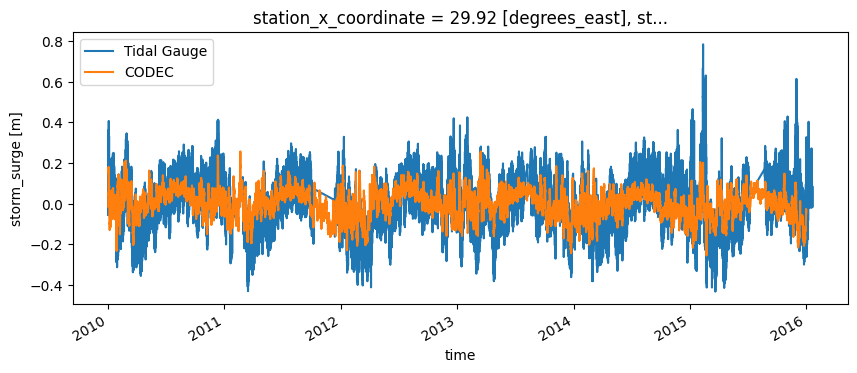

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
alexandria_tidal_gauge["SS-MSL"].plot(figsize=(10, 4), label="Tidal Gauge", ax=ax)
alexandria_codec.surge.plot(label="CODEC", ax=ax)
ax.legend()

In [11]:
bathy = xr.open_dataset("inputs/bathymetry/EMODNET_alexandria.nc")
bathy

<xarray.Dataset> Size: 2MB
Dimensions:    (lat: 512, lon: 1184)
Coordinates:
  * lon        (lon) float64 9kB 28.6 28.6 28.61 28.61 ... 32.29 32.29 32.3
  * lat        (lat) float64 4kB 30.6 30.6 30.61 30.61 ... 32.19 32.19 32.2
Data variables:
    elevation  (lat, lon) float32 2MB ...

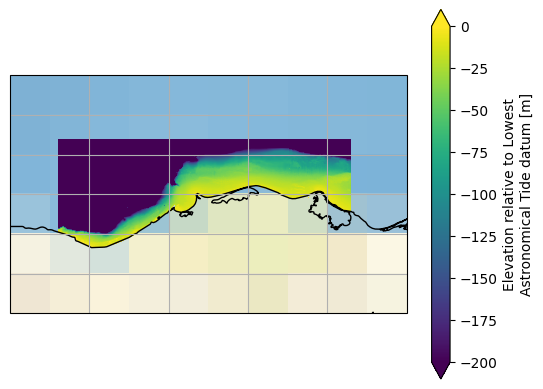

In [12]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

bathy.elevation.plot(
    transform=ccrs.PlateCarree(), ax=ax, cmap="viridis", vmin=-200, vmax=0
)
ax.coastlines()
ax.gridlines()
ax.set_extent((28, 33, 30, 33))
ax.stock_img()

In [13]:
spectra = xr.open_dataset("inputs/waves/WHACS_202001_spectra.nc").rename(
    {"__xarray_dataarray_variable__": "efth"}
)
spectra

<xarray.Dataset> Size: 7MB
Dimensions:   (time: 744, freq: 38, dir: 30)
Coordinates:
  * time      (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    seapoint  int32 4B ...
  * freq      (freq) float64 304B 0.03 0.04 0.05 0.06 ... 0.37 0.38 0.39 0.4
  * dir       (dir) int64 240B 0 12 24 36 48 60 72 ... 288 300 312 324 336 348
Data variables:
    efth      (time, freq, dir) float64 7MB ...

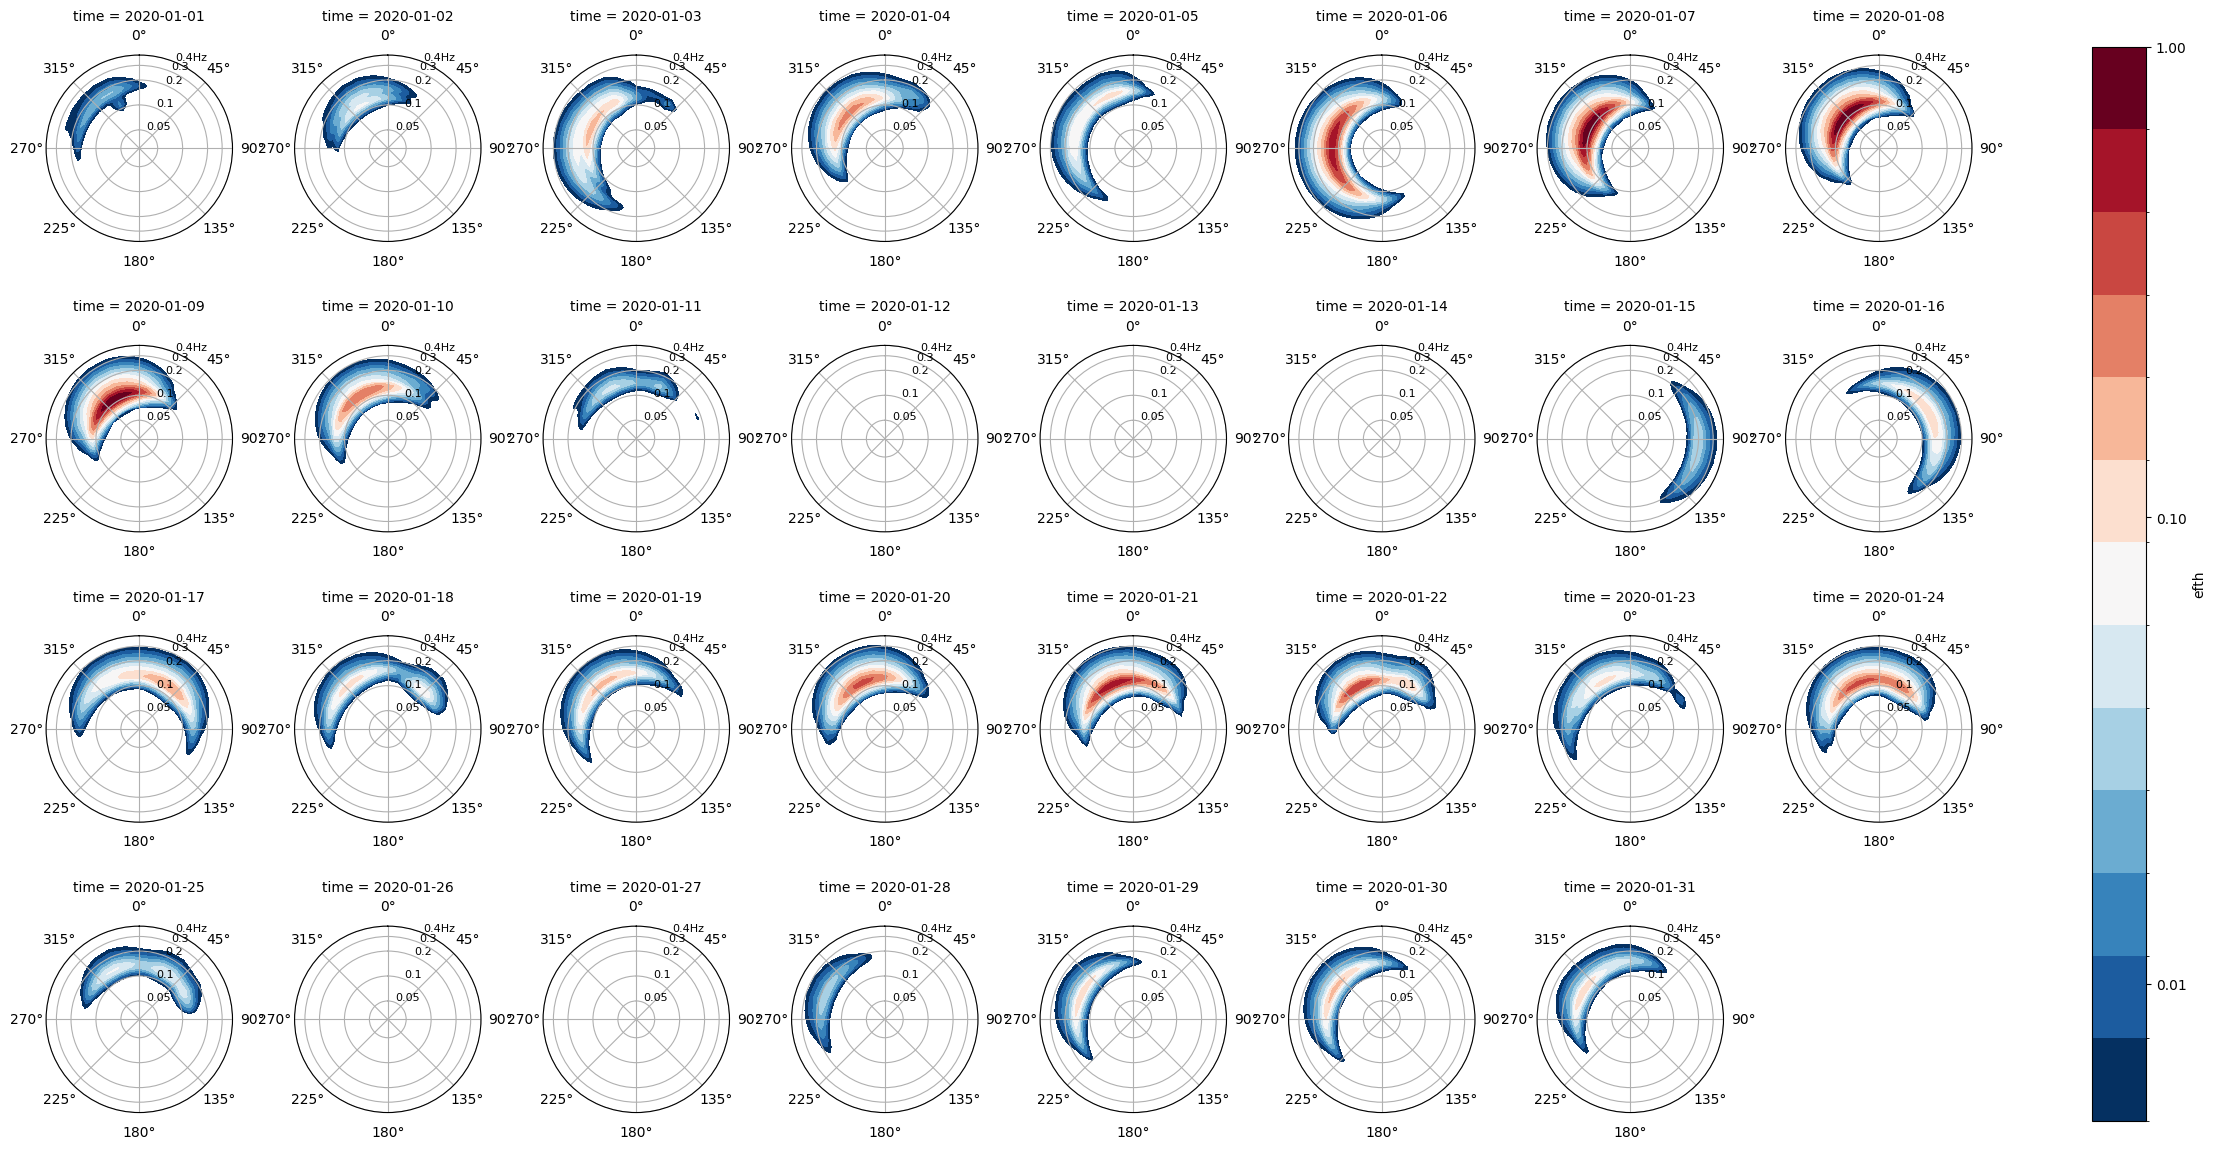

In [14]:
spectra.efth.resample(time="1D").mean().spec.plot(col="time", col_wrap=8)